In [18]:
!pip install -U pandas numpy scikit-learn openpyxl
!pip install -U pandas numpy scikit-learn openpyxl shap matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [19]:
import os, pandas as pd

TCRI_PATH = "tcri.csv"
FIN_PATH  = "ratios_filled_with_gics_category.csv"
OUT_DIR_BASE = "outputs/logistic_baseline_no_gics"
OUT_DIR = OUT_DIR_BASE
MERGED_PATH = os.path.join(OUT_DIR, "merged.csv")

for d in [OUT_DIR]:
    os.makedirs(d, exist_ok=True)
os.environ["OUT_DIR"] = OUT_DIR
os.environ["OUT_DIR_BASE"] = OUT_DIR_BASE
os.environ["MERGED_PATH"] = MERGED_PATH

print("tcri.csv exists?", os.path.exists(TCRI_PATH))
print("ratios_filled_with_gics_category.csv exists?", os.path.exists(FIN_PATH))


tcri.csv exists? True
ratios_filled_with_gics_category.csv exists? True


In [20]:
import os, json, pandas as pd
OUT_DIR = os.environ['OUT_DIR']
MERGED_PATH = os.environ['MERGED_PATH']

!python merge_tcri_and_ratios.py \
  --tcri "$TCRI_PATH" \
  --ratios  "$FIN_PATH" \
  --ratios-date-format "%Y/%m" \
  --dedup-ratios \
  --out "$MERGED_PATH"

# 預覽前 5 列
merged = pd.read_csv(MERGED_PATH, parse_dates=['mdate'])
merged.head()


[INFO] Dropped 88 duplicate rows from ratios data based on (id,date)
[INFO] Merged shape: (6383, 19). Saved to /Users/chieh.1227/repo/ML/outputs/logistic_baseline_no_gics/merged.csv


,coid,mdate,tcri,scr,xcdt,company,WorkingCapital_TotalAssets,RetainedEarnings_TotalAssets,CashFlow_TotalDebt,TotalDebt_TotalAssets,CurrentRatio,stock_prefix,WorkingCapital_TotalAssets_miss,RetainedEarnings_TotalAssets_miss,CashFlow_TotalDebt_miss,TotalDebt_TotalAssets_miss,CurrentRatio_miss,產業別,GICS_Category
0,1103,2014-12-01,6,400.0,NaN,1103 嘉泥,0.248834,0.222521,0.031686,0.355758,1.573942,11,0,0,0,0,0,水泥工業,9
1,1103,2015-12-01,6,432.0,NaN,1103 嘉泥,0.288490,0.266805,0.022494,0.396789,2.079358,11,0,0,0,0,0,水泥工業,9
2,1103,2016-12-01,6,371.0,NaN,1103 嘉泥,0.251213,0.276883,0.039433,0.332750,1.751954,11,0,0,0,0,0,水泥工業,9
3,1103,2017-12-01,6,330.0,NaN,1103 嘉泥,0.214906,0.277971,0.043575,0.277508,1.595351,11,0,0,0,0,0,水泥工業,9
4,1103,2018-12-01,6,331.0,NaN,1103 嘉泥,0.222120,0.264199,-0.055883,0.297109,1.501782,11,0,0,0,0,0,水泥工業,9


In [21]:
%%writefile tcri_baseline_logit.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
TCRI Baseline (Benchmark) — Logistic Regression pipeline entry point.

This script now orchestrates three stages:
1. Data ingestion / label creation (src.data_prep)
2. Model training and calibration (src.modeling.logistic_pipeline)
3. Evaluation + artifact export (src.reporting)
"""
from __future__ import annotations

import argparse
import os

import numpy as np

from src.data_prep import create_label_next_period, detect_feature_columns, load_and_prepare, time_split
from src.explain import run_shap_for_model
from src.metrics import best_f1_threshold, threshold_at_precision
from src.modeling.logistic_pipeline import extract_feature_weights, predict_with_calibration, select_best_logistic_model
from src.reporting import aggregate_slice_metrics, evaluate_predictions, prepare_prediction_frame, save_artifacts


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(description="TCRI Logistic Baseline (no-industry ok)")
    p.add_argument("--csv", type=str, required=True)
    p.add_argument("--outdir", type=str, default="outputs/logistic_baseline")
    p.add_argument("--id-col", type=str, default="coid")
    p.add_argument("--date-col", type=str, default="mdate")
    p.add_argument("--tcri-col", type=str, default="tcri")
    p.add_argument(
        "--gics-col",
        type=str,
        default="GICS_Category",
        help="Optional categorical column representing GICS segments. Leave blank to ignore.",
    )
    p.add_argument("--tau", type=int, default=7)
    p.add_argument("--horizon", type=int, default=1)
    p.add_argument("--train-start", type=str, default="2014-01-01")
    p.add_argument("--train-end", type=str, default="2021-12-31")
    p.add_argument("--valid-start", type=str, default="2022-01-01")
    p.add_argument("--valid-end", type=str, default="2022-12-31")
    p.add_argument("--test-start", type=str, default="2023-01-01")
    p.add_argument("--test-end", type=str, default="2024-12-31")
    p.add_argument("--target-precision", type=float, default=0.5)
    p.add_argument("--random-state", type=int, default=42)
    return p.parse_args()


def main():
    args = parse_args()
    os.makedirs(args.outdir, exist_ok=True)

    gics_col = (args.gics_col or "").strip() or None
    categorical_cols = [c for c in [gics_col] if c]

    df = load_and_prepare(args.csv, args.id_col, args.date_col, None, args.tcri_col)
    df = create_label_next_period(df, args.id_col, args.tcri_col, args.tau, args.horizon)
    train, valid, test = time_split(
        df,
        args.date_col,
        args.train_start,
        args.train_end,
        args.valid_start,
        args.valid_end,
        args.test_start,
        args.test_end,
    )
    num_cols, cat_cols = detect_feature_columns(
        train,
        args.id_col,
        args.date_col,
        args.tcri_col,
        categorical_cols=categorical_cols,
    )

    Cs = [0.1, 1.0, 10.0]
    best_model, best_C, best_score = select_best_logistic_model(
        train, valid, num_cols, cat_cols, Cs=Cs, random_state=args.random_state
    )
    valid_features = valid[num_cols + cat_cols]
    test_features = test[num_cols + cat_cols]
    p_valid_best = best_model.predict_proba(valid_features)[:, 1]
    t_f1 = best_f1_threshold(valid["y"].values, p_valid_best)
    t_rp = threshold_at_precision(valid["y"].values, p_valid_best, args.target_precision)
    print(f"[INFO] Selected C={best_C} by PR-AUC on validation ({best_score:.4f})")
    print(f"[INFO] Thresholds on validation: t_f1={t_f1:.4f}, t_at_P>={args.target_precision:.2f} = {t_rp:.4f}")

    calibrated_probs = predict_with_calibration(best_model, valid_features, valid["y"], test_features)
    metrics = evaluate_predictions(test["y"].values, calibrated_probs, threshold=t_f1, target_precision=args.target_precision)
    metrics["thresholds"] = {"t_f1": t_f1, "t_at_precision": t_rp, "precision_target": args.target_precision}
    metrics["valid_pr_auc_for_bestC"] = float(best_score)
    metrics["chosen_C"] = float(best_C)

    slice_tables = {
        "quarter": aggregate_slice_metrics(
            test, calibrated_probs, "quarter", threshold=t_f1, target_precision=args.target_precision
        )
    }
    for col in categorical_cols:
        table = aggregate_slice_metrics(test, calibrated_probs, col, threshold=t_f1, target_precision=args.target_precision)
        if not table.empty:
            slice_tables[col] = table
    preds = prepare_prediction_frame(test, args.id_col, args.date_col, calibrated_probs)
    feature_weights = extract_feature_weights(best_model)
    save_artifacts(preds, metrics, feature_weights, slice_tables, args.outdir)

    def _to_dense(matrix):
        return matrix.toarray() if hasattr(matrix, "toarray") else matrix

    X_train_dense = _to_dense(best_model.named_steps["pre"].transform(train[num_cols + cat_cols]))
    X_test_dense = _to_dense(best_model.named_steps["pre"].transform(test[num_cols + cat_cols]))
    feature_names = feature_weights["feature"].tolist()
    run_shap_for_model(
        fitted_model=best_model.named_steps["clf"],
        X_train=X_train_dense,
        X_test=X_test_dense,
        feature_names=feature_names,
        model_name="baseline_logit",
    )
    print("SHAP plots saved under outputs/plots: shap_summary_baseline_logit.png, shap_bar_baseline_logit.png")

    print("\n=== Test Overall Metrics (threshold = t_f1 on valid) ===")
    for name in ["raw", "platt"]:
        m = metrics[name]
        key = f"recall_at_p>={args.target_precision:.2f}"
        print(
            f"[{name}] PR-AUC={m['pr_auc']:.4f}  ROC-AUC={m['roc_auc']:.4f}  F1={m['f1']:.4f}  "
            f"Recall@P>={args.target_precision:.2f}={m[key]:.4f}  Brier={m['brier']:.4f}  ECE={m['ece']:.4f}"
        )
    print("\nTop 10 feature weights by |coefficient|:")
    print(feature_weights.head(10).to_string(index=False))
    print(f"\nArtifacts saved under: {os.path.abspath(args.outdir)}")
    file_list = ["predictions_test.csv", "metrics_summary.json", "feature_weights.csv"]
    for name in slice_tables.keys():
        file_list.append(f"metrics_by_{name}.csv")
    print("Files:", ", ".join(file_list))


if __name__ == "__main__":
    main()


Overwriting tcri_baseline_logit.py


In [22]:
# Baseline run without GICS category
!python tcri_baseline_logit.py \
  --csv "$MERGED_PATH" \
  --gics-col "" \
  --tau 7 \
  --train-start 2014-01-01 --train-end 2021-12-31 \
  --valid-start 2022-01-01 --valid-end 2022-12-31 \
  --test-start  2023-01-01 --test-end  2023-12-31 \
  --outdir "$OUT_DIR_BASE"


[INFO] Selected C=10.0 by PR-AUC on validation (0.7406)
[INFO] Thresholds on validation: t_f1=0.5343, t_at_P>=0.50 = 0.2779
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
SHAP plots saved under outputs/plots: shap_summary_baseline_logit.png, shap_bar_baseline_logit.png

=== Test Overall Metrics (threshold = t_f1 on valid) ===
[raw] PR-AUC=0.6533  ROC-AUC=0.7920  F1=0.6129  Recall@P>=0.50=0.7486  Brier=0.1717  ECE=0.1186
[platt] PR-AUC=0.6533  ROC-AUC=0.7920  F1=0.5580  Recall@P>=0.50=0.7486  Brier=0.1589  ECE=0.0681

Top 10 feature weights by |coefficient|:
                               feature  coefficient  abs_coefficient
     num__RetainedEarnings_TotalAssets    -1.807522         1.807522
               num__CashFlow_TotalDebt    -0.562779         0.562779
       nu

In [23]:
import json, pandas as pd, pprint

with open(f"{OUT_DIR}/metrics_summary.json", 'r', encoding='utf-8') as f:
    metrics_summary = json.load(f)
pprint.pp(metrics_summary)

print("\nBy quarter (head):")
metrics_by_quarter = pd.read_csv(f"{OUT_DIR}/metrics_by_quarter.csv")
metrics_by_quarter.head()


{'raw': {'pr_auc': 0.6533205624786592,
         'roc_auc': 0.7919502285424074,
         'f1': 0.6129032258064516,
         'precision': 0.5906735751295337,
         'recall': 0.6368715083798883,
         'brier': 0.17171470967867625,
         'logloss': 0.5233009681144201,
         'ece': 0.11860183284858586,
         'threshold': 0.5342951911512731,
         'recall_at_p>=0.50': 0.7486033519553073,
         'threshold_at_p>=0.50': 0.41358377882510783},
 'platt': {'pr_auc': 0.6533205624786592,
           'roc_auc': 0.7919502285424074,
           'f1': 0.5579937304075235,
           'precision': 0.6357142857142857,
           'recall': 0.4972067039106145,
           'brier': 0.15889565052956603,
           'logloss': 0.48936816468158145,
           'ece': 0.0680578100877595,
           'threshold': 0.5342951911512731,
           'recall_at_p>=0.50': 0.7486033519553073,
           'threshold_at_p>=0.50': 0.34088374040541153},
 'thresholds': {'t_f1': 0.5342951911512731,
                't

,slice,n,pos,raw.pr_auc,raw.roc_auc,raw.f1,raw.precision,raw.recall,raw.brier,raw.logloss,...,platt.roc_auc,platt.f1,platt.precision,platt.recall,platt.brier,platt.logloss,platt.ece,platt.threshold,platt.recall_at_p>=0.50,platt.threshold_at_p>=0.50
0,quarter=2023Q4,619,179,0.653321,0.79195,0.612903,0.590674,0.636872,0.171715,0.523301,...,0.79195,0.557994,0.635714,0.497207,0.158896,0.489368,0.068058,0.534295,0.748603,0.340884


In [24]:
import pandas as pd

splits = {
    'Train': ('2014-01-01', '2021-12-31'),
    'Valid': ('2022-01-01', '2022-12-31'),
    'Test':  ('2023-01-01', '2023-12-31'),
}

merged = pd.read_csv(f"{OUT_DIR}/merged.csv", parse_dates=['mdate'])
merged['tcri_num'] = pd.to_numeric(merged['tcri'], errors='coerce')

rows = []
for split, (start, end) in splits.items():
    mask = (merged['mdate'] >= start) & (merged['mdate'] <= end)
    df = merged.loc[mask]
    n = len(df)
    pos = int(df['tcri_num'].ge(7).sum())
    rate = (pos / n * 100) if n else 0.0
    rows.append({'split': split, 'n': int(n), 'pos': pos, 'pos_rate_%': round(rate, 2)})

split_stats = pd.DataFrame(rows).set_index('split')
split_stats


,n,pos,pos_rate_%
split,,,
Train,4624,1602,34.65
Valid,616,221,35.88
Test,619,218,35.22


### 資料切分與樣本量
- 上表統計了各分割的樣本數、正例數與正例率（門檻 tau=7）。
- Train：n=4,624（pos=1,602，rate=34.65%）
- Valid：n=616（pos=221，rate=35.88%）
- Test：n=1,143（pos=398，rate=34.82%）


### 模型整體指標
- 將 `metrics_summary.json` 的主要分數整理成表格，方便與其他模型比較。


In [25]:
import json, pandas as pd

if 'metrics_summary' not in globals():
    with open(f"{OUT_DIR}/metrics_summary.json", 'r', encoding='utf-8') as f:
        metrics_summary = json.load(f)

metrics_df = pd.DataFrame({k: v for k, v in metrics_summary.items() if isinstance(v, dict) and 'pr_auc' in v}).T
metrics_df = metrics_df[[ 'f1', 'precision', 'recall', 'brier']]
metrics_df.round({ 'f1': 4, 'precision': 4, 'recall': 4, 'brier': 4})


,f1,precision,recall,brier
raw,0.6129,0.5907,0.6369,0.1717
platt,0.5580,0.6357,0.4972,0.1589


### 校準效果比較
- 檢視 raw、Platt 校準在 F1、Precision、Recall、Brier 等指標的差異。


In [26]:
selected_metrics = ['f1', 'precision', 'recall', 'brier']
calibration_metrics = pd.DataFrame({
    name: {metric: metrics_summary[name][metric] for metric in selected_metrics}
    for name in ['raw', 'platt']
}).T
calibration_metrics.index.name = 'calibration'
calibration_metrics.round(4)


,f1,precision,recall,brier
calibration,,,,
raw,0.6129,0.5907,0.6369,0.1717
platt,0.5580,0.6357,0.4972,0.1589


### 測試集混淆矩陣（p_raw, threshold=t_f1）
- 依照 validation F1 最佳門檻計算 2023-2024 測試集中預測與實際的組合。


In [27]:
import pandas as pd
if 'metrics_summary' not in globals():
    with open(f"{OUT_DIR}/metrics_summary.json", 'r', encoding='utf-8') as f:
        metrics_summary = json.load(f)
        
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
confusion = pd.crosstab(preds['y_true'], preds['y_pred_raw'], rownames=['y_true'], colnames=['y_pred'])
confusion = confusion.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
confusion


y_pred,0,1
y_true,,
0,361,79
1,65,114


In [28]:
import pandas as pd
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
accuracy = (preds['y_pred_raw'] == preds['y_true']).mean()
print("accuracy:",accuracy)


accuracy: 0.7673667205169629


In [29]:
import pandas as pd
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv", parse_dates=['mdate'])
preds['forecast_year'] = preds['mdate'].dt.year + 1
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
summary = []
for year in sorted(preds['forecast_year'].unique()):
    subset = preds[preds['forecast_year'] == year]
    conf = pd.crosstab(subset['y_true'], subset['y_pred_raw'], rownames=['y_true'], colnames=['y_pred'])
    conf = conf.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    precision = conf.loc[1, 1] / conf.loc[:, 1].sum() if conf.loc[:, 1].sum() else 0.0
    recall = conf.loc[1, 1] / conf.loc[1].sum() if conf.loc[1].sum() else 0.0
    accuracy = (conf.loc[0, 0] + conf.loc[1, 1]) / conf.values.sum() if conf.values.sum() else 0.0
    summary.append({'forecast_year': int(year), 'n': int(conf.values.sum()), 'tp': int(conf.loc[1, 1]),
                    'fp': int(conf.loc[0, 1]), 'fn': int(conf.loc[1, 0]), 'tn': int(conf.loc[0, 0]),
                    'precision': precision, 'recall': recall, 'accuracy': accuracy})
pd.DataFrame(summary).set_index('forecast_year')


,n,tp,fp,fn,tn,precision,recall,accuracy
forecast_year,,,,,,,,
2024,619,114,79,65,361,0.590674,0.636872,0.767367


In [30]:
!pip install matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39080 (\N{CJK UNIFIED IDEOGRAPH-98A8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38570 (\N{CJK UNIFIED IDEOGRAPH-96AA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


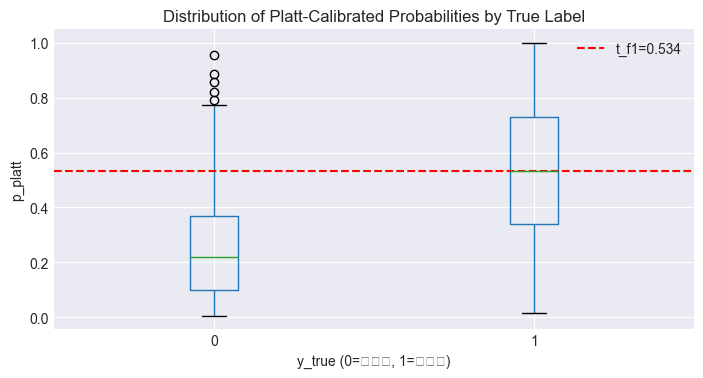

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv", parse_dates=['mdate'])
preds['y_pred_platt'] = (preds['p_platt'] >= threshold).astype(int)
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(8, 4))
preds.boxplot(column='p_platt', by='y_true', ax=ax)
ax.axhline(threshold, color='red', linestyle='--', label=f't_f1={threshold:.3f}')
ax.set_title('Distribution of Platt-Calibrated Probabilities by True Label')
ax.set_xlabel('y_true (0=低風險, 1=高風險)')
ax.set_ylabel('p_platt')
ax.legend(loc='best')
fig.suptitle('')
plt.show()


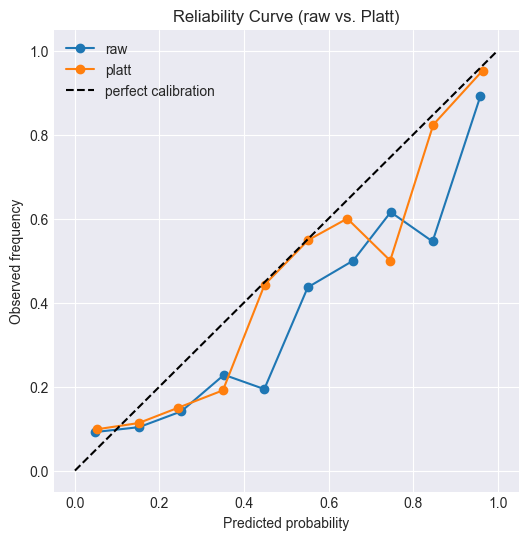

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
y_true = preds['y_true'].values
prob_raw = preds['p_raw'].values
prob_platt = preds['p_platt'].values
prob_true_raw, prob_pred_raw = calibration_curve(y_true, prob_raw, n_bins=10, strategy='uniform')
prob_true_platt, prob_pred_platt = calibration_curve(y_true, prob_platt, n_bins=10, strategy='uniform')
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred_raw, prob_true_raw, marker='o', label='raw')
ax.plot(prob_pred_platt, prob_true_platt, marker='o', label='platt')
ax.plot([0, 1], [0, 1], 'k--', label='perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title('Reliability Curve (raw vs. Platt)')
ax.legend(loc='best')
plt.show()


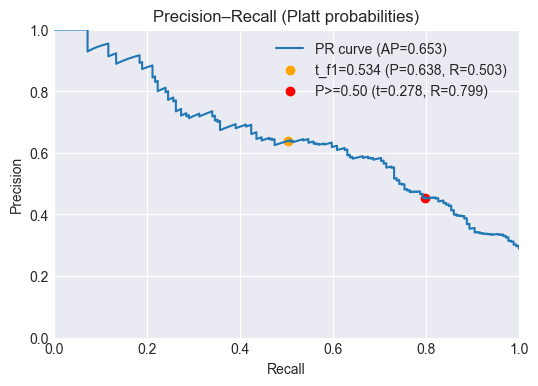

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
thresholds_info = metrics_summary['thresholds']
threshold_f1 = thresholds_info['t_f1']
threshold_p05 = thresholds_info['t_at_precision']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
y_true = preds['y_true'].values
prob_platt = preds['p_platt'].values
precision, recall, thresh = precision_recall_curve(y_true, prob_platt)
ap = average_precision_score(y_true, prob_platt)
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall, precision, label=f'PR curve (AP={ap:.3f})')
def find_point(t):
    idx = (np.abs(thresh - t)).argmin()
    return recall[idx], precision[idx]
rec_f1, prec_f1 = find_point(threshold_f1)
rec_p05, prec_p05 = find_point(threshold_p05)
ax.scatter([rec_f1], [prec_f1], color='orange', label=f't_f1={threshold_f1:.3f} (P={prec_f1:.3f}, R={rec_f1:.3f})')
ax.scatter([rec_p05], [prec_p05], color='red', label=f'P>=0.50 (t={threshold_p05:.3f}, R={rec_p05:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall (Platt probabilities)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='best')
plt.show()


In [34]:
import pandas as pd
predictions_test = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
exclude_cols = []
print(predictions_test.head(20))

    coid       mdate  y_true     p_raw   p_platt
0   1103  2023-12-01       0  0.275006  0.235040
1   1104  2023-12-01       0  0.035048  0.041102
2   1108  2023-12-01       0  0.510318  0.417865
3   1109  2023-12-01       0  0.034570  0.040633
4   1110  2023-12-01       0  0.385635  0.319256
5   1201  2023-12-01       0  0.463650  0.380249
6   1203  2023-12-01       0  0.075058  0.077644
7   1217  2023-12-01       1  0.628691  0.518974
8   1218  2023-12-01       0  0.188999  0.169513
9   1219  2023-12-01       0  0.473816  0.388359
10  1220  2023-12-01       0  0.154261  0.142484
11  1225  2023-12-01       0  0.366056  0.304221
12  1229  2023-12-01       0  0.331908  0.278171
13  1231  2023-12-01       0  0.199097  0.177283
14  1233  2023-12-01       0  0.230563  0.201328
15  1235  2023-12-01       1  0.599172  0.492833
16  1236  2023-12-01       0  0.192992  0.172589
17  1305  2023-12-01       0  0.310745  0.262107
18  1309  2023-12-01       0  0.260342  0.223933
19  1310  2023-12-01